In [48]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [49]:
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

In [50]:
IN_double_mutation = "C140D-D148B"
pair1, pair2 = functions.split_pairs(IN_double_mutation)
wt1,pos1,mt1 = functions.split_pair(pair1)
wt2,pos2,mt2 = functions.split_pair(pair2)
IN_seq_w_mutation = [seq for seq in IN_all_seq if seq[pos1-1] == mt1 and seq[pos2-1] == mt2]
print(len(IN_seq_w_mutation))

221


In [51]:
p_SH_all = [functions.calculate_double_mutant_probablity(seq, 'C140D', 'D148B', IN_J, 1, 263) for seq in IN_seq_w_mutation]
lowest_prob_indices = sorted(range(len(p_SH_all)), key=p_SH_all.__getitem__)[:10]
highest_prob_indices = sorted(range(len(p_SH_all)), key=p_SH_all.__getitem__, reverse=True)[:10]

print("10 lowest probability indices:", lowest_prob_indices)
print("10 highest probability indices:", highest_prob_indices)


10 lowest probability indices: [47, 4, 25, 19, 44, 216, 203, 219, 43, 123]
10 highest probability indices: [172, 193, 55, 92, 210, 70, 0, 88, 190, 74]


In [52]:
min_position = 1
max_position = 263

print("Lowest probability indices and values:", [(i, p_SH_all[i]) for i in lowest_prob_indices])
print("Highest probability indices and values:", [(i, p_SH_all[i]) for i in highest_prob_indices])

Lowest probability indices and values: [(47, 0.007800793463008116), (4, 0.028399198721585844), (25, 0.03629026601253644), (19, 0.05293623759243532), (44, 0.061805707433160474), (216, 0.06347403329018718), (203, 0.08040587285169684), (219, 0.09282344926178461), (43, 0.09960123704315765), (123, 0.1073738893249246)]
Highest probability indices and values: [(172, 0.9920179375618225), (193, 0.9916040563588459), (55, 0.9907137598656011), (92, 0.9865013227062998), (210, 0.985960115614258), (70, 0.9767480412742192), (0, 0.9730512870129445), (88, 0.9729018823109195), (190, 0.9721211738209948), (74, 0.9661677256170271)]


In [53]:
vectors_top10 = [functions.vectorize_seq_residue_energy(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in highest_prob_indices]
vectors_bottom10 = [functions.vectorize_seq_residue_energy(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in lowest_prob_indices]
print(sum(vectors_top10[0])/2)
print(sum(vectors_bottom10[0])/2)

with open('top_bottom_vectors.txt', 'w') as f:
    f.write("TOP_VECTORS\n")
    for v in vectors_top10:
        f.write(repr([float(x) for x in v]) + "\n")

    f.write("\nBOTTOM_VECTORS\n")
    for v in vectors_bottom10:
        f.write(repr([float(x) for x in v]) + "\n")

print("Wrote top_bottom_vectors.txt")

-1553.3956
-1530.8302
Wrote top_bottom_vectors.txt


In [54]:
# # verify vectorization on consensus sequence
# consensus_E = functions.calculate_e(IN_consensus_seq, IN_J, min_position, max_position)
# print(consensus_E)

# consensus_residue_E_vector = functions.vectorize_seq_residue_energy(IN_consensus_seq, IN_J, min_position, max_position)
# print(sum(consensus_residue_E_vector)/2)


In [55]:
# #verify E values for top and bottom sequences
# E_top10 = [functions.calculate_e(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in highest_prob_indices]
# E_bottom10 = [functions.calculate_e(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in lowest_prob_indices]
# print("E values for top 10 highest probability sequences:", E_top10)
# print("E values for top 10 lowest probability sequences:", E_bottom10)


PC1 top 10 important positions (energy encoding):
  pos 156: importance=0.2615, loading=+0.2615
  pos 148: importance=0.2596, loading=+0.2596
  pos  97: importance=0.2109, loading=+0.2109
  pos 208: importance=0.2009, loading=+0.2009
  pos  17: importance=0.1841, loading=+0.1841
  pos  79: importance=0.1670, loading=+0.1670
  pos 112: importance=0.1622, loading=+0.1622
  pos  10: importance=0.1541, loading=+0.1541
  pos  84: importance=0.1492, loading=-0.1492
  pos 219: importance=0.1484, loading=-0.1484

PC2 top 10 important positions (energy encoding):
  pos 220: importance=0.3254, loading=+0.3254
  pos  17: importance=0.2408, loading=+0.2408
  pos  79: importance=0.2088, loading=-0.2088
  pos  50: importance=0.1768, loading=+0.1768
  pos  66: importance=0.1740, loading=-0.1740
  pos 151: importance=0.1623, loading=+0.1623
  pos  24: importance=0.1616, loading=+0.1616
  pos  45: importance=0.1533, loading=+0.1533
  pos  97: importance=0.1529, loading=-0.1529
  pos 258: importance=0.

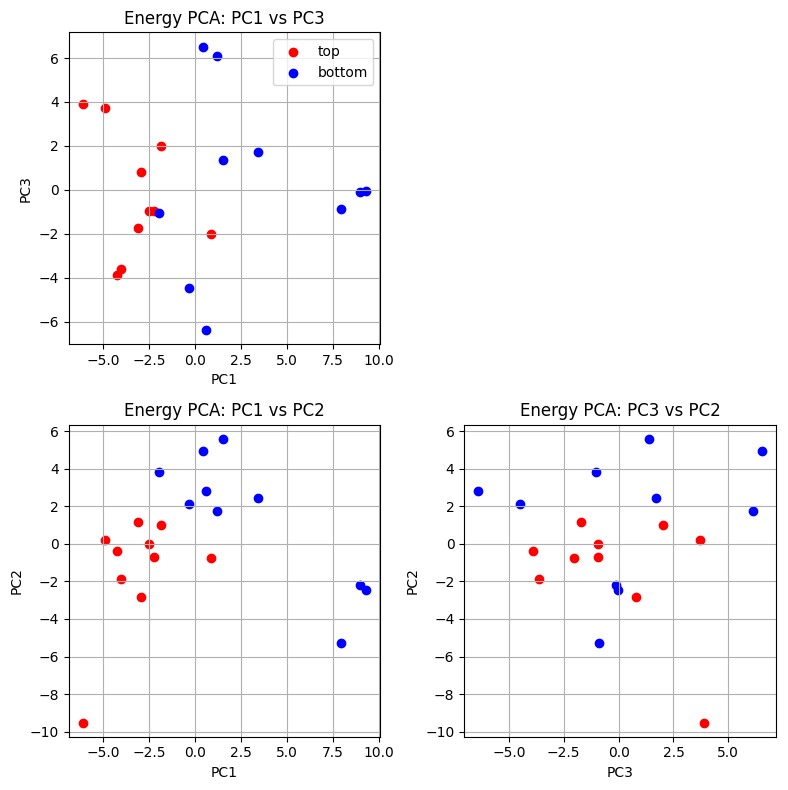

In [56]:
import numpy as np
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Energy-per-residue encoding and PCA on most/least probable sequences

# build matrix from existing per-residue energy vectors
X_top = np.array(vectors_top10, dtype=np.float32)   # shape: (10, L)
X_bot = np.array(vectors_bottom10, dtype=np.float32) # shape: (10, L)
X = np.vstack([X_top, X_bot])                        # shape: (20, L)
labels = np.array([1]*len(X_top) + [0]*len(X_bot))

# PCA in 3D (same style as one-hot section)
pca_e = PCA(n_components=3)
Xe_pca = pca_e.fit_transform(X)

# Interpret PCs directly by position loadings
# components_: shape (3, L)
pc_loadings_e = pca_e.components_          # shape (3, L)
start_pos = min_position if 'min_position' in globals() else 1
top_n = 10

for pc_idx in range(3):
    # absolute weight at each position
    pos_importance = np.abs(pc_loadings_e[pc_idx])   # shape: (L,)
    # indices of the top‑n positions, sorted descending
    top_pos_idx = np.argsort(pos_importance)[::-1][:top_n]

    print(f"\nPC{pc_idx+1} top {top_n} important positions (energy encoding):")
    for j in top_pos_idx:
        loading = pc_loadings_e[pc_idx, j]
        print(f"  pos {start_pos + j:>3}: importance={pos_importance[j]:.4f}, loading={loading:+.4f}")

print("Explained variance ratio (energy):", pca_e.explained_variance_ratio_)

plt.figure(figsize=(8, 8))

# Top-left: PC1 vs PC3
ax1 = plt.subplot(2, 2, 1)
ax1.scatter(Xe_pca[labels==1, 0], Xe_pca[labels==1, 2], c='r', marker='o', label='top')
ax1.scatter(Xe_pca[labels==0, 0], Xe_pca[labels==0, 2], c='b', marker='o', label='bottom')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC3'); ax1.set_title('Energy PCA: PC1 vs PC3')
ax1.legend(); ax1.grid(True); ax1.set_box_aspect(1)

# Bottom-left: PC1 vs PC2
ax2 = plt.subplot(2, 2, 3)
ax2.scatter(Xe_pca[labels==1, 0], Xe_pca[labels==1, 1], c='r', marker='o', label='top')
ax2.scatter(Xe_pca[labels==0, 0], Xe_pca[labels==0, 1], c='b', marker='o', label='bottom')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_title('Energy PCA: PC1 vs PC2')
ax2.grid(True); ax2.set_box_aspect(1)

# Bottom-right: PC3 vs PC2
ax3 = plt.subplot(2, 2, 4)
ax3.scatter(Xe_pca[labels==1, 2], Xe_pca[labels==1, 1], c='r', marker='o', label='top')
ax3.scatter(Xe_pca[labels==0, 2], Xe_pca[labels==0, 1], c='b', marker='o', label='bottom')
ax3.set_xlabel('PC3'); ax3.set_ylabel('PC2'); ax3.set_title('Energy PCA: PC3 vs PC2')
ax3.grid(True); ax3.set_box_aspect(1)

# Top-right empty
ax4 = plt.subplot(2, 2, 2)
ax4.axis('off')

plt.tight_layout()
plt.show()


PC1 top 10 important positions:
  pos 124: importance=0.3040, strongest residue='C' (loading=+0.3040)
  pos 201: importance=0.2652, strongest residue='A' (loading=-0.2652)
  pos  31: importance=0.2468, strongest residue='A' (loading=-0.2468)
  pos 156: importance=0.2028, strongest residue='A' (loading=+0.2028)
  pos 112: importance=0.1863, strongest residue='D' (loading=+0.1583)
  pos 135: importance=0.1591, strongest residue='C' (loading=-0.1591)
  pos  17: importance=0.1547, strongest residue='A' (loading=-0.1547)
  pos 101: importance=0.1438, strongest residue='B' (loading=-0.1438)
  pos 208: importance=0.1424, strongest residue='C' (loading=-0.1424)
  pos  97: importance=0.1096, strongest residue='A' (loading=-0.1096)

PC2 top 10 important positions:
  pos  25: importance=0.2774, strongest residue='A' (loading=+0.2774)
  pos  11: importance=0.2680, strongest residue='A' (loading=-0.2680)
  pos 138: importance=0.1519, strongest residue='B' (loading=+0.1519)
  pos  84: importance=0.

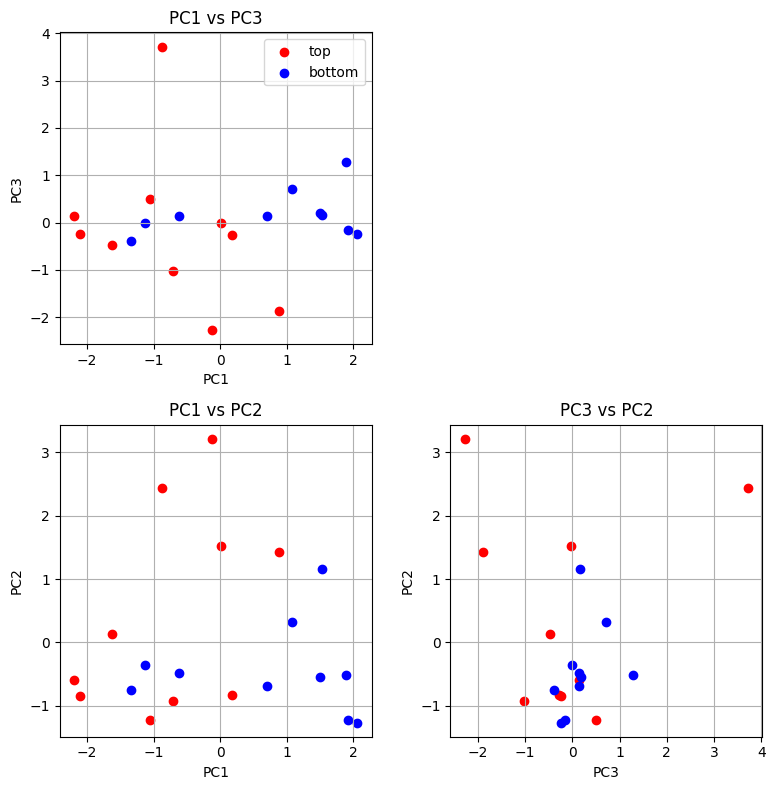

In [57]:
# One-hot encode sequences (per-residue) and run PCA on most/least probable sequences

# select sequences
top_seqs = [IN_seq_w_mutation[i] for i in highest_prob_indices]
bot_seqs = [IN_seq_w_mutation[i] for i in lowest_prob_indices]

# build alphabet from available sequences to ensure proper mapping
alphabet = sorted({ch for seq in IN_all_seq for ch in seq})
char2idx = {ch: idx for idx, ch in enumerate(alphabet)}
L = len(top_seqs[0])  # sequence length
K = len(alphabet)     # one-hot depth

def seq_one_hot_flat(seq):
    mat = np.zeros((L, K), dtype=np.float32)
    for j, ch in enumerate(seq):
        mat[j, char2idx[ch]] = 1.0
    return mat.ravel()

X_top_ohe = np.vstack([seq_one_hot_flat(s) for s in top_seqs])
X_bot_ohe = np.vstack([seq_one_hot_flat(s) for s in bot_seqs])
X_ohe = np.vstack([X_top_ohe, X_bot_ohe])
labels_ohe = np.array([1]*len(X_top_ohe) + [0]*len(X_bot_ohe))

pca_ohe = PCA(n_components=3)
Xo_pca = pca_ohe.fit_transform(X_ohe)

# Interpret PCs: map loadings back to sequence positions
# components_: shape (3, L*K) -> reshape to (3, L, K)
pc_loadings = pca_ohe.components_.reshape(3, L, K)

start_pos = min_position if 'min_position' in globals() else 1
top_n = 10

for pc_idx in range(3):
    # importance of each position for this PC (aggregate across residues)
    pos_importance = np.sum(np.abs(pc_loadings[pc_idx]), axis=1)/2  # shape: (L,)
    top_pos_idx = np.argsort(pos_importance)[::-1][:top_n]

    print(f"\nPC{pc_idx+1} top {top_n} important positions:")
    for j in top_pos_idx:
        # residue with largest absolute loading at this position
        residue_idx = np.argmax(np.abs(pc_loadings[pc_idx, j]))
        residue = alphabet[residue_idx]
        loading = pc_loadings[pc_idx, j, residue_idx]
        print(
            f"  pos {start_pos + j:>3}: importance={pos_importance[j]:.4f}, "
            f"strongest residue='{residue}' (loading={loading:+.4f})"
        )
print("Explained variance ratio (one-hot):", pca_ohe.explained_variance_ratio_)

plt.figure(figsize=(8, 8))

# Top-left: PC1 vs PC3
ax1 = plt.subplot(2, 2, 1)
ax1.scatter(Xo_pca[labels_ohe==1, 0], Xo_pca[labels_ohe==1, 2], c='r', marker='o', label='top')
ax1.scatter(Xo_pca[labels_ohe==0, 0], Xo_pca[labels_ohe==0, 2], c='b', marker='o', label='bottom')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC3'); ax1.set_title('PC1 vs PC3')
ax1.legend(); ax1.grid(True)
ax1.set_box_aspect(1)  # square subplot

# Bottom-left: PC1 vs PC2
ax2 = plt.subplot(2, 2, 3)
ax2.scatter(Xo_pca[labels_ohe==1, 0], Xo_pca[labels_ohe==1, 1], c='r', marker='o', label='top')
ax2.scatter(Xo_pca[labels_ohe==0, 0], Xo_pca[labels_ohe==0, 1], c='b', marker='o', label='bottom')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_title('PC1 vs PC2')
ax2.grid(True)
ax2.set_box_aspect(1)  # square subplot

# Bottom-right: PC3 vs PC2 (flipped axes)
ax3 = plt.subplot(2, 2, 4)
ax3.scatter(Xo_pca[labels_ohe==1, 2], Xo_pca[labels_ohe==1, 1], c='r', marker='o', label='top')
ax3.scatter(Xo_pca[labels_ohe==0, 2], Xo_pca[labels_ohe==0, 1], c='b', marker='o', label='bottom')
ax3.set_xlabel('PC3'); ax3.set_ylabel('PC2'); ax3.set_title('PC3 vs PC2')
ax3.grid(True)
ax3.set_box_aspect(1)  # square subplot

# Top-right left empty
ax4 = plt.subplot(2, 2, 2)
ax4.axis('off')

plt.tight_layout()
plt.show()

X_trans.shape: (526, 10)
Explained variance ratio: [0.6541856  0.07536391]


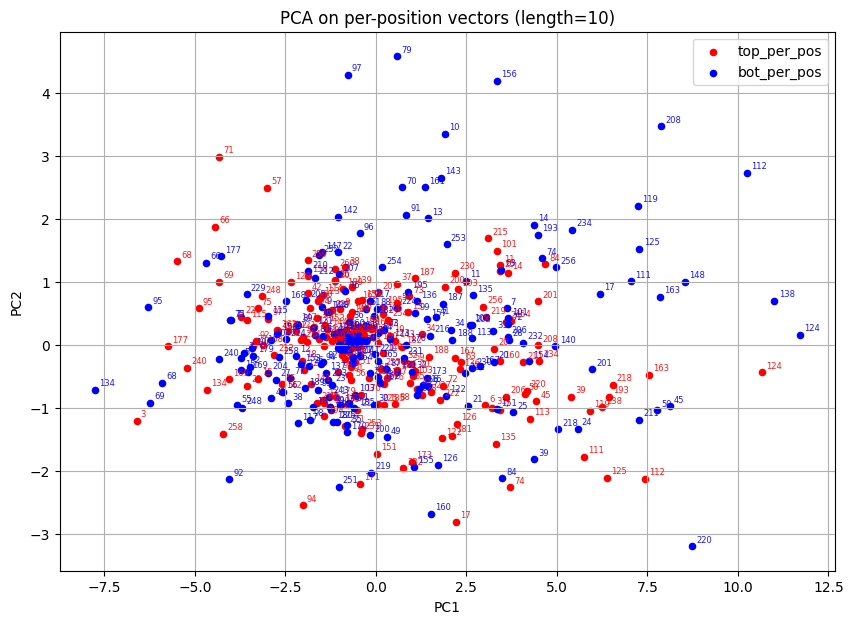

In [58]:
# Build per-position vectors of length 10 for top and bottom groups, then run PCA
data_top = X_top.T              # shape: (max_position, 10)
data_bot = X_bot.T              # shape: (max_position, 10)

X_trans = np.vstack([data_top, data_bot])   # shape: (max_position*2, 10)
labels_trans = np.array([1]*max_position + [0]*max_position)

pca2 = PCA(n_components=2)
X_trans_pca = pca2.fit_transform(X_trans)

print("X_trans.shape:", X_trans.shape)
print("Explained variance ratio:", pca2.explained_variance_ratio_)

plt.figure(figsize=(10,7))
plt.scatter(X_trans_pca[labels_trans==1,0], X_trans_pca[labels_trans==1,1], c='r', s=20, label='top_per_pos')
plt.scatter(X_trans_pca[labels_trans==0,0], X_trans_pca[labels_trans==0,1], c='b', s=20, label='bot_per_pos')

# annotate each point with its position index (1-based, using min_position)
for i, (x,y) in enumerate(X_trans_pca):
    pos = (i % max_position) + min_position
    col = 'r' if labels_trans[i]==1 else 'b'
    plt.annotate(str(pos), xy=(x,y), xytext=(3,3), textcoords='offset points',
                 fontsize=6, color=col, alpha=0.9)

plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.title('PCA on per-position vectors (length=10)'); plt.grid(True)
plt.show()